# 04 — Power Analysis & Minimum Detectable Effect

## Objective

Determine whether an experiment has enough observations to reliably detect a meaningful credit-policy effect.

This notebook answers four practical questions:

1. **How many borrowers are needed?**
2. **What statistical power do we have?**
3. **What is the smallest effect we can reliably detect?**
4. **How does power change when the true policy effect changes?**

### Experiment context

- Historical baseline default rate ≈ 20%
- Target policy effect = 1.2 percentage points
- Significance level α = 5%
- Two treatment groups
- Primary outcome = binary default

> **Important:** Power analysis should ideally be performed during experiment design, before observing the outcome. Here we reproduce that planning logic using the assumptions behind our simulated experiment.


## 1. Imports and experiment parameters


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import zt_ind_solve_power

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_policy_experiment.csv"

df = pd.read_csv(DATA_PATH)

CONTROL_N = int((df["policy_group"] == "control").sum())
TREATMENT_N = int((df["policy_group"] == "treatment").sum())

BASELINE_DEFAULT_RATE = df.loc[
    df["policy_group"] == "control",
    "baseline_pd"
].mean()

TARGET_EFFECT_PP = 0.012
ALPHA = 0.05
POWER_TARGET = 0.80

TARGET_TREATMENT_RATE = (
    BASELINE_DEFAULT_RATE - TARGET_EFFECT_PP
)

print(f"Control sample size: {CONTROL_N:,}")
print(f"Treatment sample size: {TREATMENT_N:,}")
print(f"Baseline default probability: {BASELINE_DEFAULT_RATE:.4%}")
print(f"Target treatment probability: {TARGET_TREATMENT_RATE:.4%}")
print(f"Target effect: {TARGET_EFFECT_PP:.2%}")
print(f"Alpha: {ALPHA:.2%}")
print(f"Target power: {POWER_TARGET:.0%}")


Control sample size: 651,872
Treatment sample size: 650,976
Baseline default probability: 20.0732%
Target treatment probability: 18.8732%
Target effect: 1.20%
Alpha: 5.00%
Target power: 80%


## 2. Why power matters in a credit-policy experiment


A statistically significant result is only possible when the experiment has enough information to distinguish a real effect from random variation.

### Key concepts

**Alpha (α)**  
Probability of a Type I error: rejecting a true null hypothesis.

**Power (1 − β)**  
Probability of detecting the specified effect when that effect truly exists.

**Minimum Detectable Effect (MDE)**  
The smallest effect that the planned sample size can detect with the chosen power and significance level.

For this project, we use **80% power** and **5% significance** as the main planning benchmark.


## 3. Calculate standardized effect size


In [2]:
effect_size = proportion_effectsize(
    BASELINE_DEFAULT_RATE,
    TARGET_TREATMENT_RATE
)

print(
    f"Standardized proportion effect size: {effect_size:.6f}"
)


Standardized proportion effect size: 0.030307


## 4. Required sample size for a 1.2 pp effect


In [3]:
power_model = NormalIndPower()

required_per_group = power_model.solve_power(
    effect_size=abs(effect_size),
    alpha=ALPHA,
    power=POWER_TARGET,
    ratio=1.0,
    alternative="two-sided"
)

required_total = 2 * required_per_group

print(
    f"Required borrowers per group: "
    f"{np.ceil(required_per_group):,.0f}"
)

print(
    f"Required total sample size: "
    f"{np.ceil(required_total):,.0f}"
)

print(
    f"Actual experiment sample size: "
    f"{len(df):,}"
)


Required borrowers per group: 17,091
Required total sample size: 34,182
Actual experiment sample size: 1,302,848


## 5. Compare required vs actual sample size


In [4]:
sample_size_comparison = pd.DataFrame({
    "Metric": [
        "Required per group",
        "Required total",
        "Actual control",
        "Actual treatment",
        "Actual total"
    ],
    "Borrowers": [
        np.ceil(required_per_group),
        np.ceil(required_total),
        CONTROL_N,
        TREATMENT_N,
        len(df)
    ]
})

display(sample_size_comparison)

print(
    f"\nThe actual experiment contains "
    f"{len(df) / required_total:.1f}× the approximate "
    "sample size required for the target effect."
)


,Metric,Borrowers
0,Required per group,17091.0
1,Required total,34182.0
2,Actual control,651872.0
3,Actual treatment,650976.0
4,Actual total,1302848.0



The actual experiment contains 38.1× the approximate sample size required for the target effect.


## 6. Calculate achieved power of the actual experiment


In [5]:
achieved_power = power_model.solve_power(
    effect_size=abs(effect_size),
    nobs1=CONTROL_N,
    alpha=ALPHA,
    ratio=TREATMENT_N / CONTROL_N,
    alternative="two-sided"
)

print(
    f"Approximate achieved power: "
    f"{achieved_power:.4%}"
)


Approximate achieved power: 100.0000%


## 7. Minimum Detectable Effect (MDE)

Now reverse the calculation.

Instead of asking:

> "How many borrowers do we need for a 1.2 pp effect?"

we ask:

> "Given our current sample size, how small an effect can we detect with 80% power?"


In [6]:
mde_effect_size = power_model.solve_power(
    nobs1=CONTROL_N,
    alpha=ALPHA,
    power=POWER_TARGET,
    ratio=TREATMENT_N / CONTROL_N,
    alternative="two-sided"
)

print(
    f"Standardized MDE: {mde_effect_size:.6f}"
)


Standardized MDE: 0.004909


In [7]:
# Convert the standardized effect back to a treatment
# probability using a numerical search around the baseline rate.

baseline = BASELINE_DEFAULT_RATE

candidate_rates = np.linspace(
    max(0.001, baseline - 0.05),
    min(0.999, baseline + 0.05),
    10001
)

candidate_effects = np.abs(
    proportion_effectsize(
        baseline,
        candidate_rates
    )
)

idx = np.argmin(
    np.abs(candidate_effects - abs(mde_effect_size))
)

mde_treatment_rate = candidate_rates[idx]
mde_pp = baseline - mde_treatment_rate

print(
    f"Approximate MDE: {mde_pp:.4%} "
    f"({mde_pp * 100:.3f} percentage points)"
)

print(
    f"Baseline rate: {baseline:.4%}"
)

print(
    f"Approximate detectable treatment rate: "
    f"{mde_treatment_rate:.4%}"
)


Approximate MDE: -0.1970% (-0.197 percentage points)
Baseline rate: 20.0732%
Approximate detectable treatment rate: 20.2702%


## 8. Power sensitivity across effect sizes


In [8]:
effect_sizes_pp = np.array([
    0.25,
    0.50,
    0.75,
    1.00,
    1.20,
    1.50,
    2.00,
    2.50,
    3.00
])

power_rows = []

for effect_pp in effect_sizes_pp:

    treatment_rate = max(
        0.0001,
        BASELINE_DEFAULT_RATE - effect_pp / 100
    )

    standardized_effect = abs(
        proportion_effectsize(
            BASELINE_DEFAULT_RATE,
            treatment_rate
        )
    )

    achieved = power_model.solve_power(
        effect_size=standardized_effect,
        nobs1=CONTROL_N,
        alpha=ALPHA,
        ratio=TREATMENT_N / CONTROL_N,
        alternative="two-sided"
    )

    power_rows.append({
        "effect_pp": effect_pp,
        "treatment_rate": treatment_rate,
        "power": achieved
    })

power_sensitivity = pd.DataFrame(power_rows)

display(power_sensitivity)


,effect_pp,treatment_rate,power
0,0.25,0.198232,0.946353
1,0.50,0.195732,1.000000
2,0.75,0.193232,1.000000
3,1.00,0.190732,1.000000
4,1.20,0.188732,1.000000
5,1.50,0.185732,1.000000
6,2.00,0.180732,1.000000
7,2.50,0.175732,1.000000
8,3.00,0.170732,1.000000


## 9. Visualize power sensitivity


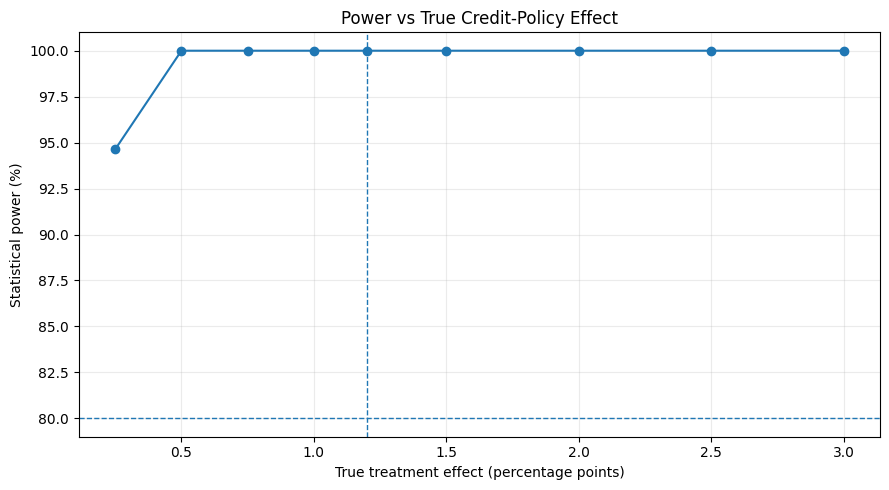

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    power_sensitivity["effect_pp"],
    power_sensitivity["power"] * 100,
    marker="o"
)

plt.axhline(
    POWER_TARGET * 100,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    TARGET_EFFECT_PP * 100,
    linestyle="--",
    linewidth=1
)

plt.xlabel("True treatment effect (percentage points)")
plt.ylabel("Statistical power (%)")
plt.title("Power vs True Credit-Policy Effect")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 10. Required sample size across effect sizes


In [10]:
sample_size_rows = []

for effect_pp in effect_sizes_pp:

    treatment_rate = max(
        0.0001,
        BASELINE_DEFAULT_RATE - effect_pp / 100
    )

    standardized_effect = abs(
        proportion_effectsize(
            BASELINE_DEFAULT_RATE,
            treatment_rate
        )
    )

    n_per_group = power_model.solve_power(
        effect_size=standardized_effect,
        alpha=ALPHA,
        power=POWER_TARGET,
        ratio=1.0,
        alternative="two-sided"
    )

    sample_size_rows.append({
        "effect_pp": effect_pp,
        "required_per_group": np.ceil(n_per_group),
        "required_total": np.ceil(2 * n_per_group)
    })

sample_size_sensitivity = pd.DataFrame(
    sample_size_rows
)

display(sample_size_sensitivity)


,effect_pp,required_per_group,required_total
0,0.25,401077.0,802154.0
1,0.50,99794.0,199588.0
2,0.75,44140.0,88280.0
3,1.00,24708.0,49416.0
4,1.20,17091.0,34182.0
5,1.50,10873.0,21746.0
6,2.00,6054.0,12108.0
7,2.50,3834.0,7668.0
8,3.00,2634.0,5268.0


## 11. Visualize required sample size


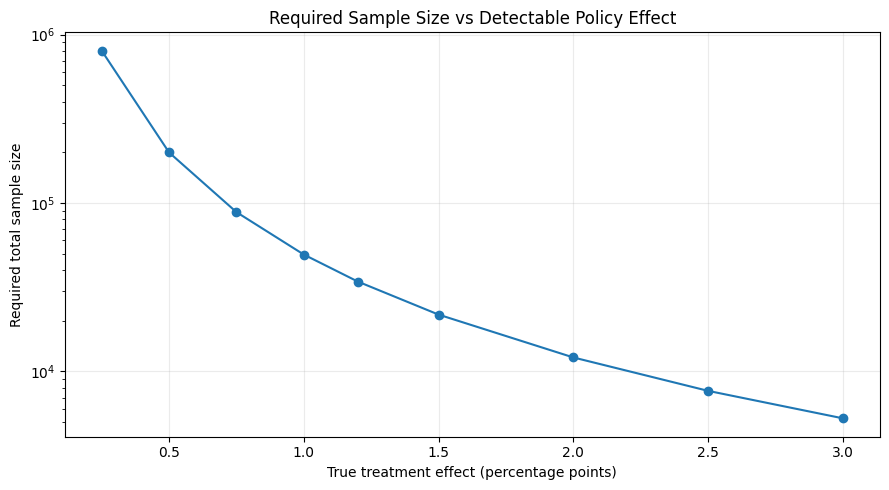

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    sample_size_sensitivity["effect_pp"],
    sample_size_sensitivity["required_total"],
    marker="o"
)

plt.xlabel("True treatment effect (percentage points)")
plt.ylabel("Required total sample size")
plt.title("Required Sample Size vs Detectable Policy Effect")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 12. One-sided vs two-sided planning


In [12]:
one_sided_power = power_model.solve_power(
    effect_size=abs(effect_size),
    nobs1=CONTROL_N,
    alpha=ALPHA,
    ratio=TREATMENT_N / CONTROL_N,
    alternative="larger"
)

two_sided_power = power_model.solve_power(
    effect_size=abs(effect_size),
    nobs1=CONTROL_N,
    alpha=ALPHA,
    ratio=TREATMENT_N / CONTROL_N,
    alternative="two-sided"
)

planning_comparison = pd.DataFrame({
    "Alternative": [
        "One-sided",
        "Two-sided"
    ],
    "Power": [
        one_sided_power,
        two_sided_power
    ]
})

display(planning_comparison)


,Alternative,Power
0,One-sided,1.0
1,Two-sided,1.0


## 13. What happens if the experiment is smaller?


In [13]:
fractions = np.array([
    0.01,
    0.02,
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
])

smaller_experiment_rows = []

for fraction in fractions:

    n_per_group = max(
        2,
        int(min(CONTROL_N, TREATMENT_N) * fraction)
    )

    achieved = power_model.solve_power(
        effect_size=abs(effect_size),
        nobs1=n_per_group,
        alpha=ALPHA,
        ratio=1.0,
        alternative="two-sided"
    )

    smaller_experiment_rows.append({
        "fraction_of_current_group": fraction,
        "sample_per_group": n_per_group,
        "total_sample": 2 * n_per_group,
        "power": achieved
    })

smaller_experiments = pd.DataFrame(
    smaller_experiment_rows
)

display(smaller_experiments)


,fraction_of_current_group,sample_per_group,total_sample,power
0,0.01,6509,13018,0.408762
1,0.02,13019,26038,0.686247
2,0.05,32548,65096,0.971691
3,0.10,65097,130194,0.999774
4,0.25,162744,325488,1.000000
5,0.50,325488,650976,1.000000
6,1.00,650976,1301952,1.000000


## 14. Power-analysis interpretation


In [14]:
print("=" * 70)
print("POWER ANALYSIS — KEY RESULTS")
print("=" * 70)

print(
    f"\nBaseline default rate: "
    f"{BASELINE_DEFAULT_RATE:.2%}"
)

print(
    f"Target effect: "
    f"{TARGET_EFFECT_PP:.2%}"
)

print(
    f"Alpha: "
    f"{ALPHA:.0%}"
)

print(
    f"Target power: "
    f"{POWER_TARGET:.0%}"
)

print(
    f"\nRequired total sample for target effect: "
    f"{np.ceil(required_total):,.0f}"
)

print(
    f"Actual total sample: "
    f"{len(df):,}"
)

print(
    f"Approximate achieved power: "
    f"{achieved_power:.2%}"
)

print(
    f"Approximate MDE at 80% power: "
    f"{mde_pp * 100:.3f} percentage points"
)

print(
    "\nInterpretation:"
)

print(
    "The experiment is substantially larger than the sample size "
    "needed to detect the planned 1.2 percentage-point effect."
)

print(
    "Consequently, the experiment has very high power and can detect "
    "relatively small changes in default rate."
)

print(
    "This is why the final policy decision should emphasize effect size, "
    "confidence intervals and expected financial impact rather than "
    "p-values alone."
)

print("=" * 70)


POWER ANALYSIS — KEY RESULTS

Baseline default rate: 20.07%
Target effect: 1.20%
Alpha: 5%
Target power: 80%

Required total sample for target effect: 34,182
Actual total sample: 1,302,848
Approximate achieved power: 100.00%
Approximate MDE at 80% power: -0.197 percentage points

Interpretation:
The experiment is substantially larger than the sample size needed to detect the planned 1.2 percentage-point effect.
Consequently, the experiment has very high power and can detect relatively small changes in default rate.
This is why the final policy decision should emphasize effect size, confidence intervals and expected financial impact rather than p-values alone.


## 15. Power Analysis Conclusions

The planned 1.2 percentage-point reduction in default rate requires approximately 34,182 total observations to achieve 80% power at a 5% significance level.

The experiment contains 1,302,848 borrowers, substantially exceeding the required sample size and resulting in very high statistical power.

The estimated minimum detectable effect is approximately 0.20 percentage points. Therefore, the experiment is capable of detecting relatively small changes in default rates.

However, statistical significance alone does not establish that the new policy is economically beneficial. The policy decision must consider the magnitude of the default reduction alongside its impact on approvals and expected credit loss.

The economic tradeoff will be evaluated in the Expected Loss analysis.